In [2]:
import pandas as pd

data = pd.read_csv("customer_data.csv")

data.head()

,CustomerID,Age,Salary,Purchased
0,1,22,25000,0
1,2,25,32000,0
2,3,47,49000,1
3,4,52,65000,1
4,5,46,78000,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   CustomerID  50 non-null     int64
 1   Age         50 non-null     int64
 2   Salary      50 non-null     int64
 3   Purchased   50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB


In [4]:
data.isnull().sum()

CustomerID    0
Age           0
Salary        0
Purchased     0
dtype: int64

In [5]:
X = data[['Age', 'Salary']]

y = data['Purchased']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [10]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [12]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_predictions)

cm

array([[5, 0],
       [0, 5]])

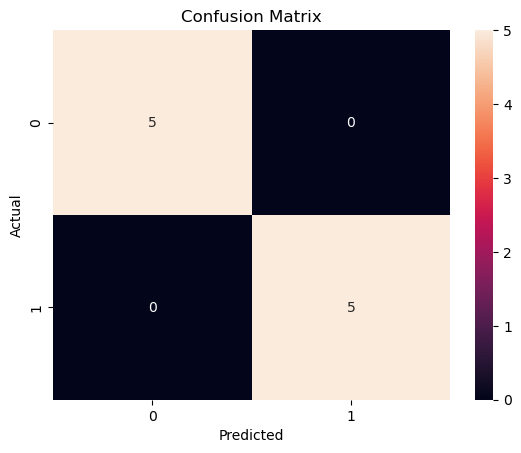

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [16]:
from sklearn.metrics import roc_curve

rf_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

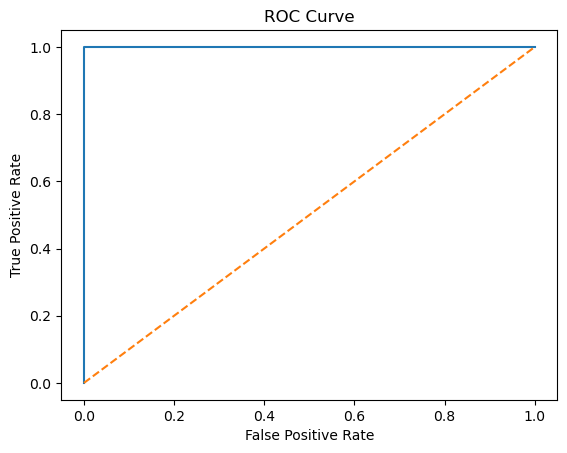

In [17]:
plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [18]:
print("Logistic Regression Accuracy:", lr_accuracy)

print("Decision Tree Accuracy:", dt_accuracy)

print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


# Conclusion

This project successfully implemented predictive modeling using machine learning techniques.

Algorithms used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The dataset was divided into training and testing data for model evaluation.

Accuracy scores were calculated for each model, and visualizations like Confusion Matrix and ROC Curve were generated.

Among all models, Random Forest produced the best prediction performance.